In [20]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
# fetch dataset 
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17) 
  
# data (as pandas dataframes) 
X = breast_cancer_wisconsin_diagnostic.data.features 
y = breast_cancer_wisconsin_diagnostic.data.targets 
  
X.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   radius1             569 non-null    float64
 1   texture1            569 non-null    float64
 2   perimeter1          569 non-null    float64
 3   area1               569 non-null    float64
 4   smoothness1         569 non-null    float64
 5   compactness1        569 non-null    float64
 6   concavity1          569 non-null    float64
 7   concave_points1     569 non-null    float64
 8   symmetry1           569 non-null    float64
 9   fractal_dimension1  569 non-null    float64
 10  radius2             569 non-null    float64
 11  texture2            569 non-null    float64
 12  perimeter2          569 non-null    float64
 13  area2               569 non-null    float64
 14  smoothness2         569 non-null    float64
 15  compactness2        569 non-null    float64
 16  concavit

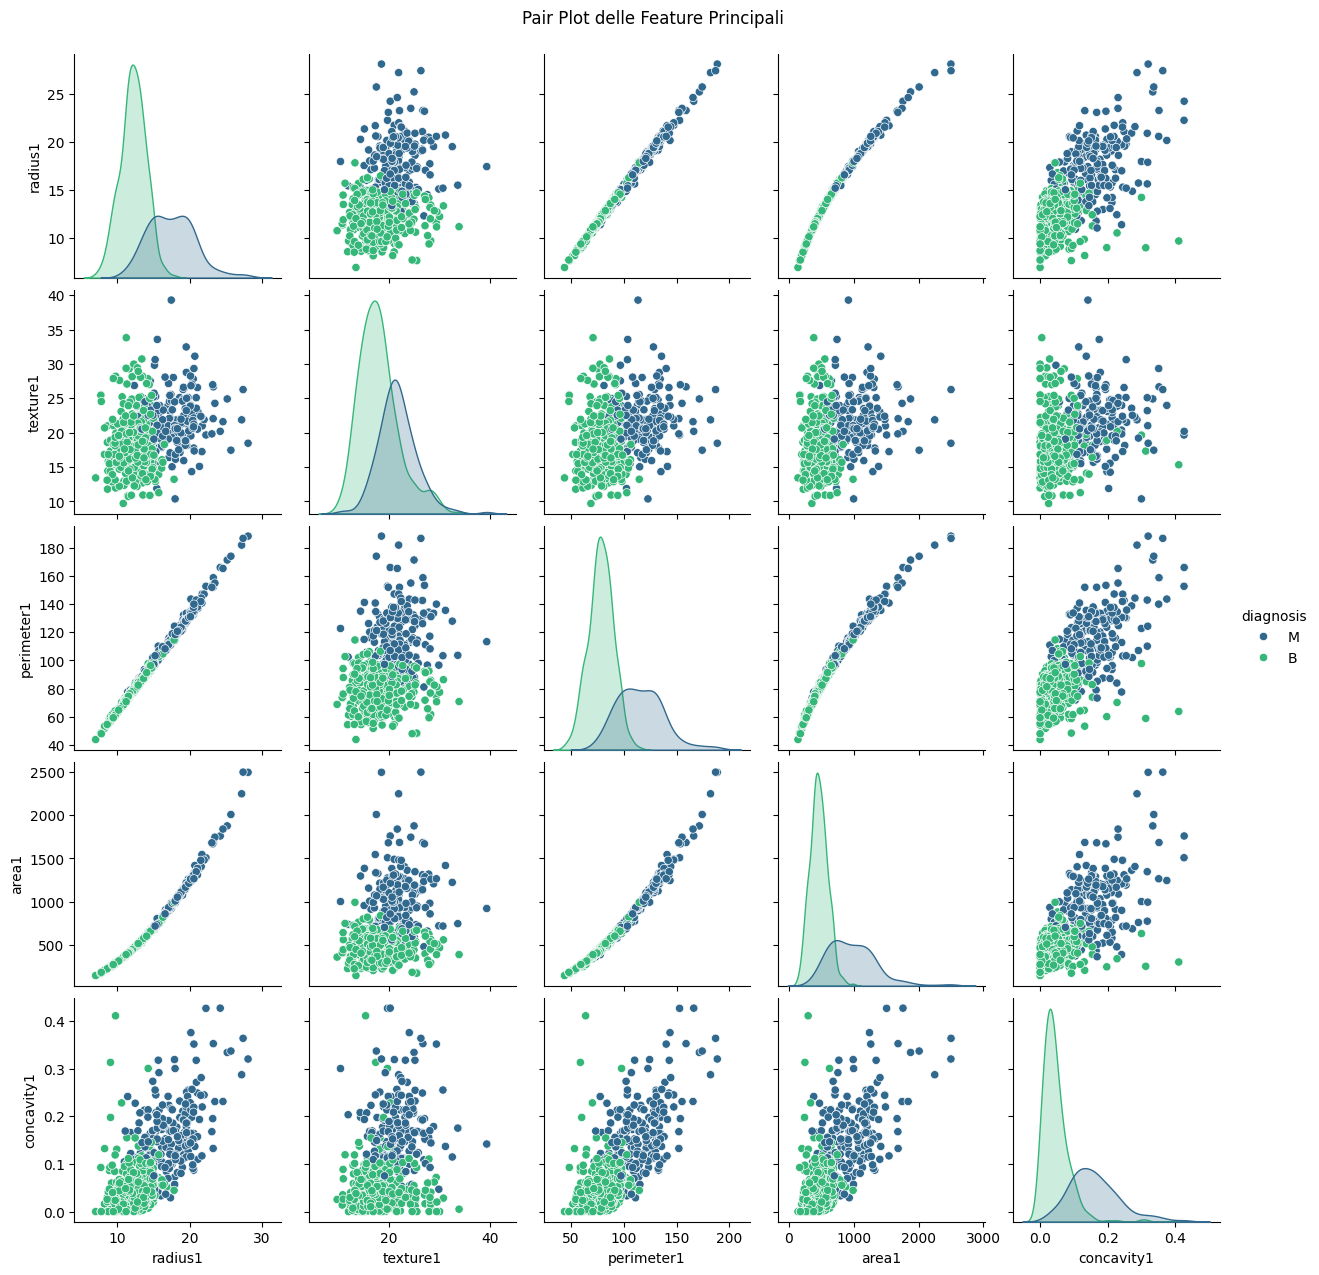

In [22]:
# Data Visualization
# Pair plot per le feature principali (primi 5 parametri)
features_to_plot = ['radius1', 'texture1', 'perimeter1', 'area1', 'concavity1']
X_plot = X[features_to_plot].copy()
X_plot['diagnosis'] = y
sns.pairplot(X_plot, hue='diagnosis', palette='viridis')
plt.suptitle('Pair Plot delle Feature Principali', y=1.02)
plt.show()

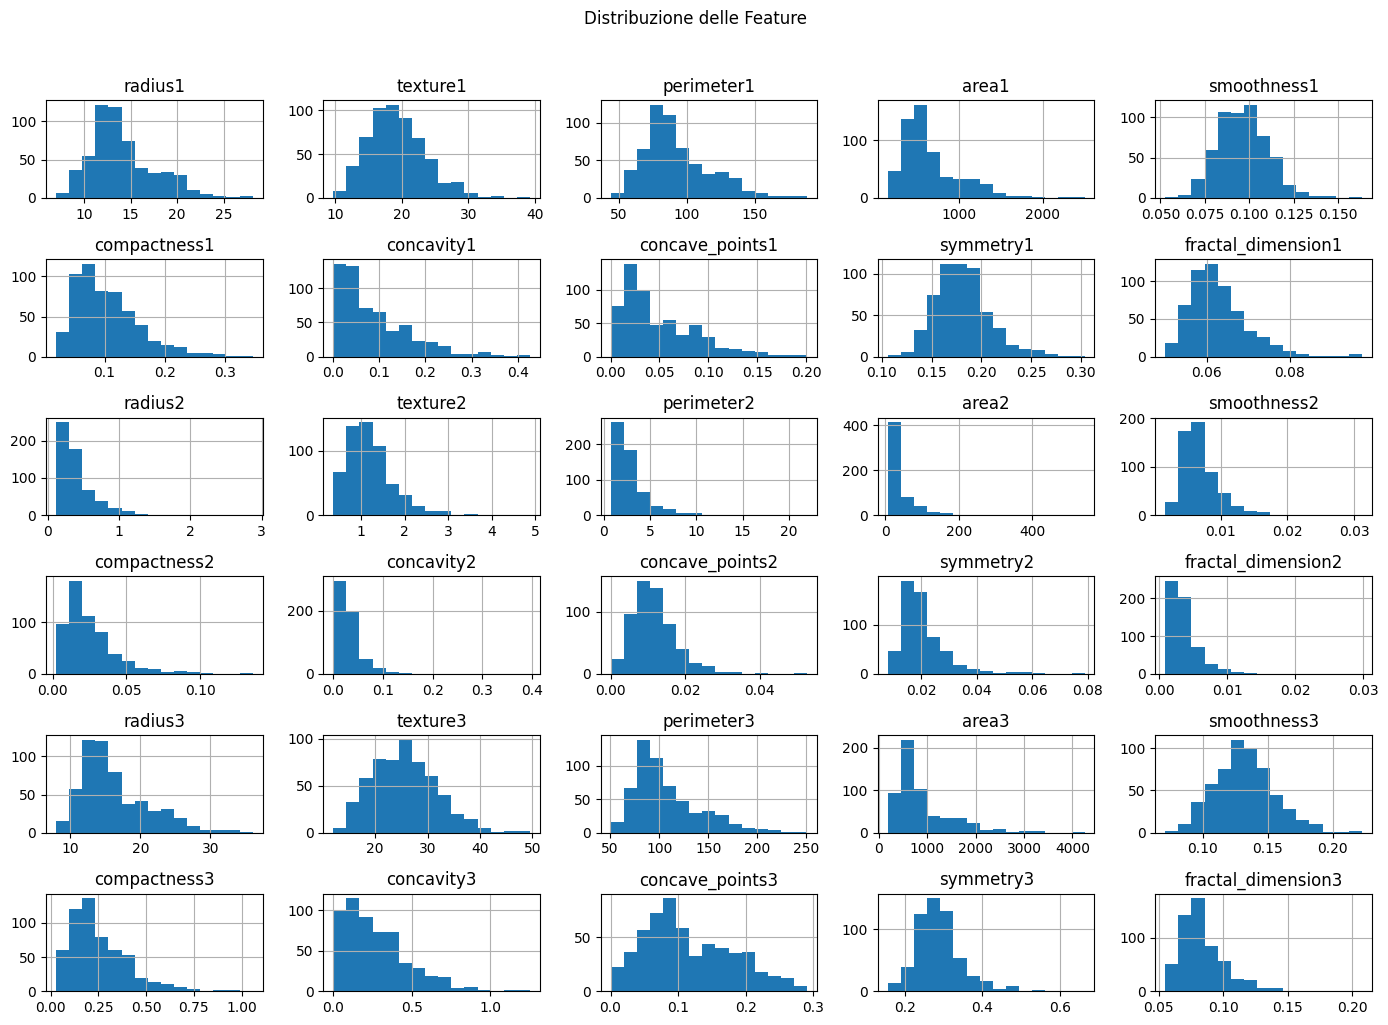

In [23]:
# Distribuzione delle feature con histogrammi
X.hist(bins=15, figsize=(14, 10))
plt.suptitle('Distribuzione delle Feature', y=1.02)
plt.tight_layout()
plt.show()

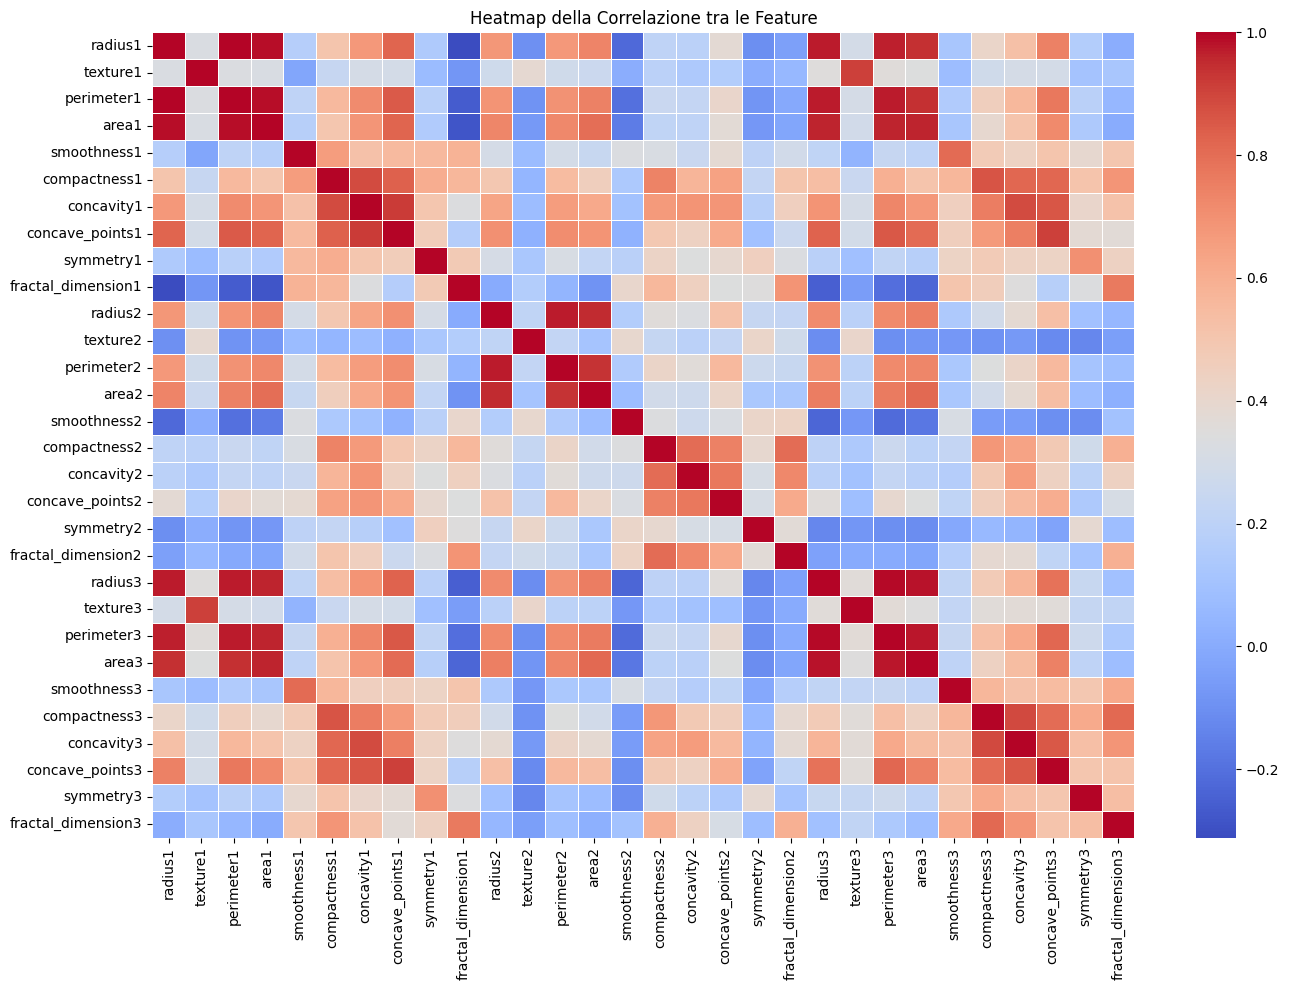

In [24]:
# Heatmap della correlazione
plt.figure(figsize=(14, 10))
correlation_matrix = X.corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Heatmap della Correlazione tra le Feature')
plt.tight_layout()
plt.show()

In [25]:
X.drop(["perimeter1", "area1", "radius3", "perimeter3", "area3", "radius2", "perimeter2", "area2"], axis=1, inplace=True)
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   radius1             569 non-null    float64
 1   texture1            569 non-null    float64
 2   smoothness1         569 non-null    float64
 3   compactness1        569 non-null    float64
 4   concavity1          569 non-null    float64
 5   concave_points1     569 non-null    float64
 6   symmetry1           569 non-null    float64
 7   fractal_dimension1  569 non-null    float64
 8   texture2            569 non-null    float64
 9   smoothness2         569 non-null    float64
 10  compactness2        569 non-null    float64
 11  concavity2          569 non-null    float64
 12  concave_points2     569 non-null    float64
 13  symmetry2           569 non-null    float64
 14  fractal_dimension2  569 non-null    float64
 15  texture3            569 non-null    float64
 16  smoothne

C:\Users\corra\AppData\Local\Temp\ipykernel_23504\161349491.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.drop(["perimeter1", "area1", "radius3", "perimeter3", "area3", "radius2", "perimeter2", "area2"], axis=1, inplace=True)


In [35]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

rfc = RandomForestClassifier(n_jobs=-1)
params = {"n_estimators":[50, 100, 150, 200],
          "criterion":["gini", "entropy", "log_loss"],
          "max_features": ["sqrt", "log2", None],
}

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
gscv = GridSearchCV(estimator=rfc, param_grid=params, cv=5)
gscv.fit(X=X_train, y=y_train)

C:\Users\corra\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
C:\Users\corra\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
C:\Users\corra\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y 

GridSearchCV(cv=5, estimator=RandomForestClassifier(n_jobs=-1),
             param_grid={'criterion': ['gini', 'entropy', 'log_loss'],
                         'max_features': ['sqrt', 'log2', None],
                         'n_estimators': [50, 100, 150, 200]})

In [46]:
print(f"Lista possibili parametri di Random Forest: \n{params}\n")
print(f"Migliori parametri con gridsearch: \n{gscv.best_params_}\n")
rfc = gscv.best_estimator_
rfc.score(X_test, y_test)
print(f"Accuracy sul test set: {rfc.score(X_test, y_test):.2f}")

Lista possibili parametri di Random Forest: 
{'n_estimators': [50, 100, 150, 200], 'criterion': ['gini', 'entropy', 'log_loss'], 'max_features': ['sqrt', 'log2', None]}

Migliori parametri con gridsearch: 
{'criterion': 'entropy', 'max_features': 'log2', 'n_estimators': 100}

Accuracy sul test set: 0.96


0.956140350877193

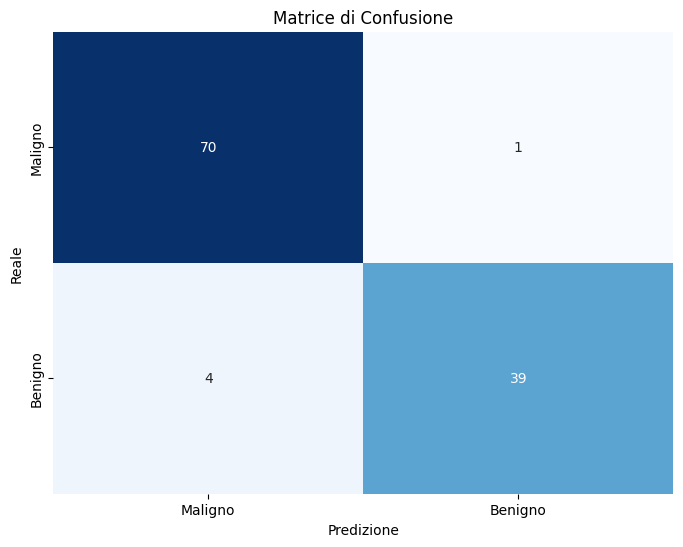

In [ ]:
# Visualizzazione dei risultati del classificatore
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

# Matrice di confusione
y_pred = rfc.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Maligno', 'Benigno'], yticklabels=['Maligno', 'Benigno'])
plt.xlabel('Predizione')
plt.ylabel('Reale')
plt.title('Matrice di Confusione')
plt.show()

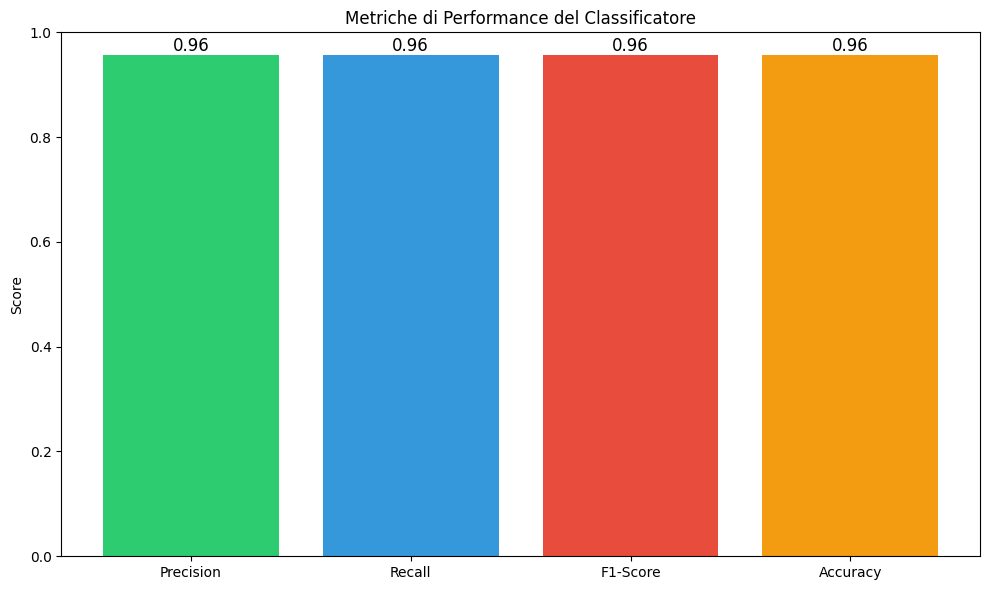

In [ ]:
# Classification Report visualizzato
from sklearn.metrics import precision_score, recall_score, f1_score

y_test_flat = y_test.values.ravel()
y_pred_flat = y_pred.ravel()

metrics = {
    'Precision': precision_score(y_test_flat, y_pred_flat, average='weighted'),
    'Recall': recall_score(y_test_flat, y_pred_flat, average='weighted'),
    'F1-Score': f1_score(y_test_flat, y_pred_flat, average='weighted'),
    'Accuracy': (y_test_flat == y_pred_flat).sum() / len(y_test_flat)
}

plt.figure(figsize=(10, 6))
bars = plt.bar(metrics.keys(), metrics.values(), color=['#2ecc71', '#3498db', '#e74c3c', '#f39c12'])
plt.ylim(0, 1.0)
plt.title('Metriche di Performance del Classificatore')
plt.ylabel('Score')

for bar, value in zip(bars, metrics.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), 
             f'{value:.2f}', ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.show()

C:\Users\corra\AppData\Local\Temp\ipykernel_23504\1355376995.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance, x='Importance', y='Feature', palette='viridis')


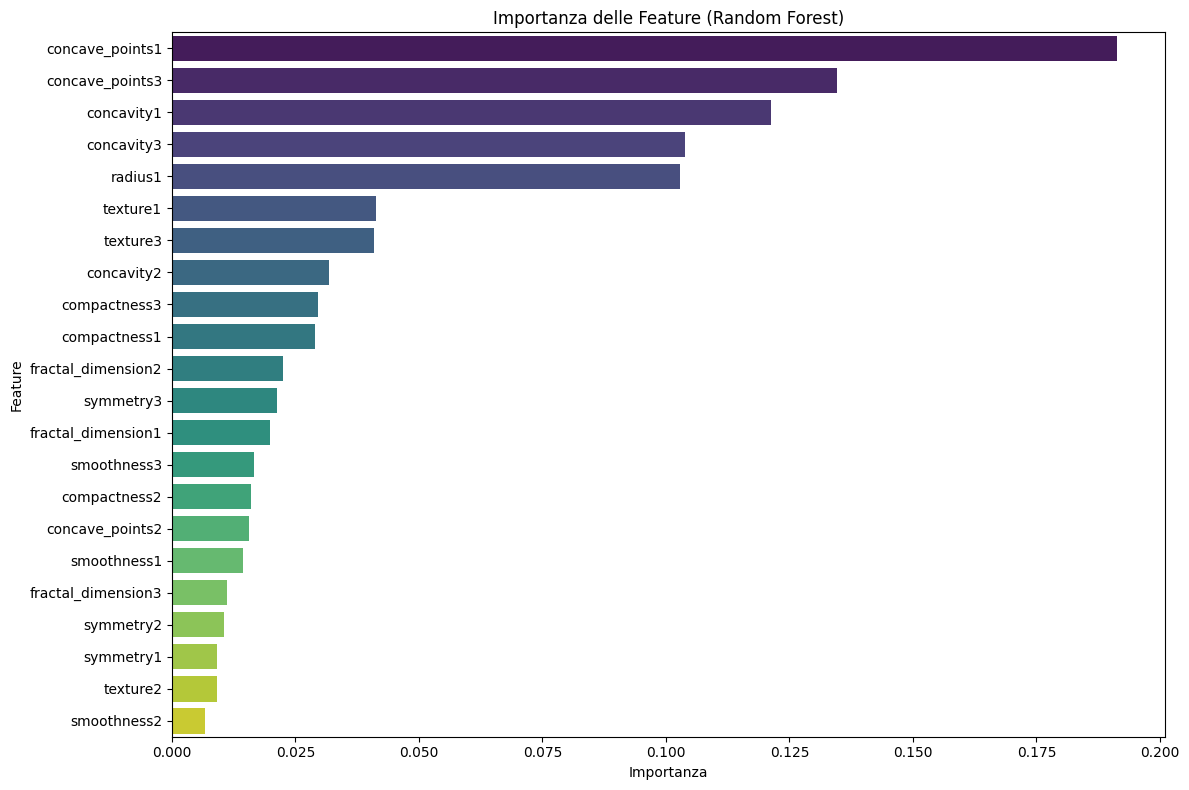

In [ ]:
# Feature Importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rfc.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(data=feature_importance, x='Importance', y='Feature', palette='viridis')
plt.title('Importanza delle Feature (Random Forest)')
plt.xlabel('Importanza')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()